In [3]:
import openmc
import numpy as np

def generate_mpower_assembly(enrichment=0.0495, poison_fraction=0.02, particles=10000, batches=50):
    """
    B&W mPower 17x17 Yarım Boy Yakıt Demeti
    Özellik: Soluble Boron Free (Suda Bor Yok), Yanabilir Zehir (Gadolinia) İçerir.
    """
    print(f"B&W mPower Modeli Oluşturuluyor. (Zenginlik: %{enrichment*100}, SBF Modu Aktif)")

    # 1. malzeme tanımlama 
    fuel = openmc.Material(name='mPower_UO2')
    fuel.set_density('g/cm3', 10.42)
    m_u = enrichment * 235.04 + (1.0 - enrichment) * 238.05
    m_o2 = 2 * 15.995 
    m_uo2 = m_u + m_o2
    fuel.add_nuclide('U235', enrichment * (m_u / m_uo2), 'wo')
    fuel.add_nuclide('U238', (1.0 - enrichment) * (m_u / m_uo2), 'wo')
    fuel.add_nuclide('O16', m_o2 / m_uo2, 'wo')

    #  Yanabilir Zehirli Yakıt (UO2 + %2 Gd2O3 - Gadolinia)
    poisoned_fuel = openmc.Material(name='mPower_UO2_Gd2O3')
    poisoned_fuel.set_density('g/cm3', 10.20) 
    poisoned_fuel.add_nuclide('U235', (enrichment * (m_u / m_uo2)) * 0.98, 'wo')
    poisoned_fuel.add_nuclide('U238', ((1.0 - enrichment) * (m_u / m_uo2)) * 0.98, 'wo')
    poisoned_fuel.add_nuclide('O16', (m_o2 / m_uo2) * 0.98, 'wo')
    poisoned_fuel.add_element('Gd', poison_fraction, 'wo')

    # Zircaloy Kılıf
    clad = openmc.Material(name='mPower_Zircaloy')
    clad.set_density('g/cm3', 6.56)
    clad.add_element('Zr', 0.9823, 'wo')
    clad.add_element('Sn', 0.0145, 'wo')
    clad.add_element('Fe', 0.0021, 'wo')
    clad.add_element('Cr', 0.0011, 'wo')

    helium = openmc.Material(name='mPower_Gap_He')
    helium.set_density('g/cm3', 0.001598)
    helium.add_element('He', 1.0)

    #  SAF SU (Borsuz)
    water = openmc.Material(name='mPower_Pure_Water')
    water.set_density('g/cm3', 0.740582) # 14.1 MPa, ~310°C çalışma şartı
    water.temperature = 583.15 # 310 Santigrat -> Kelvin
    m_H2O = 2 * 1.008 + 15.995
    water.add_element('H', (2 * 1.008) / m_H2O, 'wo')
    water.add_nuclide('O16', 15.995 / m_H2O, 'wo')

    materials = openmc.Materials([fuel, poisoned_fuel, clad, helium, water])
    materials.export_to_xml()

    # geometrik boyutlar 
    r_pellet = openmc.ZCylinder(r=0.39218)
    r_gap = openmc.ZCylinder(r=0.40005)
    r_clad = openmc.ZCylinder(r=0.45720)
    
    r_gt_in = openmc.ZCylinder(r=0.56134)
    r_gt_out = openmc.ZCylinder(r=0.60198)

    c_fuel = openmc.Cell(fill=fuel, region=-r_pellet)
    c_gap = openmc.Cell(fill=helium, region=+r_pellet & -r_gap)
    c_clad = openmc.Cell(fill=clad, region=+r_gap & -r_clad)
    c_water = openmc.Cell(fill=water, region=+r_clad)
    F = openmc.Universe(cells=[c_fuel, c_gap, c_clad, c_water])

    c_pfuel = openmc.Cell(fill=poisoned_fuel, region=-r_pellet)
    c_pgap = openmc.Cell(fill=helium, region=+r_pellet & -r_gap)
    c_pclad = openmc.Cell(fill=clad, region=+r_gap & -r_clad)
    c_pwater = openmc.Cell(fill=water, region=+r_clad)
    P = openmc.Universe(cells=[c_pfuel, c_pgap, c_pclad, c_pwater])

    # Kılavuz Tüp Evreni (G)
    c_gt_inner = openmc.Cell(fill=water, region=-r_gt_in)
    c_gt_clad = openmc.Cell(fill=clad, region=+r_gt_in & -r_gt_out)
    c_gt_water = openmc.Cell(fill=water, region=+r_gt_out)
    G = openmc.Universe(cells=[c_gt_inner, c_gt_clad, c_gt_water])

    rod_pitch = 1.25984
    offset = (17 * rod_pitch) / 2.0

    lattice = openmc.RectLattice()
    lattice.pitch = (rod_pitch, rod_pitch)
    lattice.lower_left = (-offset, -offset)
    
    # mPower için Zehirli Çubukların (P) simetrik olarak yerleştirildiği matris
    lattice.universes = [
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, P, F, P, F, F, P, F, F, F, P, F, F, P, F, P, F],
        [F, F, F, F, F, G, F, F, G, F, F, G, F, F, F, F, F],
        [F, P, F, G, F, F, F, F, F, F, F, F, F, G, F, P, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, G, F, F, G, F, F, G, F, F, G, F, F, G, F, F],
        [F, P, F, F, F, F, F, F, F, F, F, F, F, F, F, P, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, G, F, F, G, F, F, G, F, F, G, F, F, G, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, P, F, F, F, F, F, F, F, F, F, F, F, F, F, P, F],
        [F, F, G, F, F, G, F, F, G, F, F, G, F, F, G, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, P, F, G, F, F, F, F, F, F, F, F, F, G, F, P, F],
        [F, F, F, F, F, G, F, F, G, F, F, G, F, F, F, F, F],
        [F, P, F, P, F, F, P, F, F, F, P, F, F, P, F, P, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F]
    ]
    lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

    # mPower Aktif Yakıt Uzunluğu: 241.3 cm (-120.65'den +120.65'e)
    min_x = openmc.XPlane(x0=-offset, boundary_type='reflective')
    max_x = openmc.XPlane(x0=offset, boundary_type='reflective')
    min_y = openmc.YPlane(y0=-offset, boundary_type='reflective')
    max_y = openmc.YPlane(y0=offset, boundary_type='reflective')
    min_z = openmc.ZPlane(z0=-120.65, boundary_type='reflective')
    max_z = openmc.ZPlane(z0=120.65, boundary_type='reflective')

    core_box = +min_x & -max_x & +min_y & -max_y & +min_z & -max_z
    main_cell = openmc.Cell(fill=lattice, region=core_box)
    geometry = openmc.Geometry([main_cell])
    geometry.export_to_xml()

    print("B&W mPower XML dosyaları (Borsuz Mod) başarıyla üretildi.")
    return offset

In [4]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

mpower_offset = generate_mpower_assembly(enrichment=0.0495, poison_fraction=0.02, particles=10000, batches=60)

print("\nmPower Gelişmiş Sensörleri (Tallies) Kuruluyor...")

energy_bins = np.logspace(-5, 7.3, 500)
energy_filter = openmc.EnergyFilter(energy_bins)
spectrum_tally = openmc.Tally(name='Notron_Spektrumu')
spectrum_tally.filters = [energy_filter]
spectrum_tally.scores = ['flux']

spatial_mesh = openmc.RegularMesh()
spatial_mesh.dimension = [170, 170]
spatial_mesh.lower_left = [-mpower_offset, -mpower_offset]
spatial_mesh.upper_right = [mpower_offset, mpower_offset]

spatial_tally = openmc.Tally(name='Uzamsal_Haritalar')
spatial_tally.filters = [openmc.MeshFilter(spatial_mesh)]
spatial_tally.scores = ['flux', 'fission', 'absorption']

pin_mesh = openmc.RegularMesh()
pin_mesh.dimension = [17, 17]
pin_mesh.lower_left = [-mpower_offset, -mpower_offset]
pin_mesh.upper_right = [mpower_offset, mpower_offset]

pin_tally = openmc.Tally(name='Pin_Gucu')
pin_tally.filters = [openmc.MeshFilter(pin_mesh)]
pin_tally.scores = ['kappa-fission'] # Gerçek ısı üretimi

reaction_tally = openmc.Tally(name='Global_Reaksiyonlar')
reaction_tally.scores = ['(n,2n)', '(n,gamma)']

entropy_mesh = openmc.RegularMesh()
entropy_mesh.dimension = [17, 17, 1]
entropy_mesh.lower_left = [-mpower_offset, -mpower_offset, -120.65]
entropy_mesh.upper_right = [mpower_offset, mpower_offset, 120.65]

settings = openmc.Settings.from_xml()
settings.entropy_mesh = entropy_mesh
settings.export_to_xml()

tallies = openmc.Tallies([spectrum_tally, spatial_tally, pin_tally, reaction_tally])
tallies.export_to_xml()

print("\n--- B&W mPower K-EIGENVALUE VE ANALİZ SİMÜLASYONU BAŞLIYOR ---\n")
openmc.config['cross_sections'] = 'endfb-vii.1-hdf5/cross_sections.xml'
openmc.run(output=True)

B&W mPower Modeli Oluşturuluyor... (Zenginlik: %4.95, SBF Modu Aktif)
B&W mPower XML dosyaları (Borsuz Mod) başarıyla üretildi.

mPower Gelişmiş Sensörleri (Tallies) Kuruluyor...

--- B&W mPower K-EIGENVALUE VE ANALİZ SİMÜLASYONU BAŞLIYOR ---



/home/busra/miniconda3/envs/openmc/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another MeshBase instance already exists with id=3.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

mPower Reaktör Kesiti Yüksek Çözünürlükle Çiziliyor...
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %

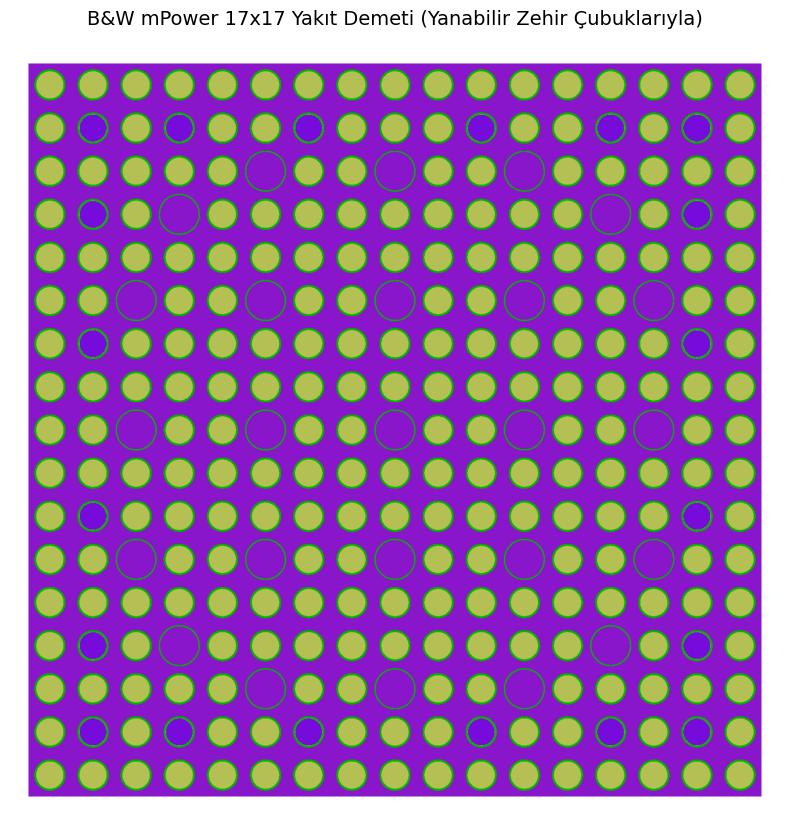

In [5]:
import matplotlib.image as mpimg

print("mPower Reaktör Kesiti Yüksek Çözünürlükle Çiziliyor...")

plot = openmc.Plot()
plot.filename = 'mpower_radial_plot'
width = mpower_offset * 2.1
plot.width = (width, width)
plot.pixels = (1500, 1500)
plot.basis = 'xy'
plot.origin = (0.0, 0.0, 0.0)
plot.color_by = 'material' 

plots = openmc.Plots([plot])
plots.export_to_xml()
openmc.plot_geometry()

try:
    img = mpimg.imread('mpower_radial_plot.png')
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title('B&W mPower 17x17 Yakıt Demeti (Yanabilir Zehir Çubuklarıyla)', fontsize=14, pad=15)
    plt.show()
except FileNotFoundError:
    print("Çizim dosyası bulunamadı.")


Sonuçlar HDF5 Dosyasından Çekiliyor.



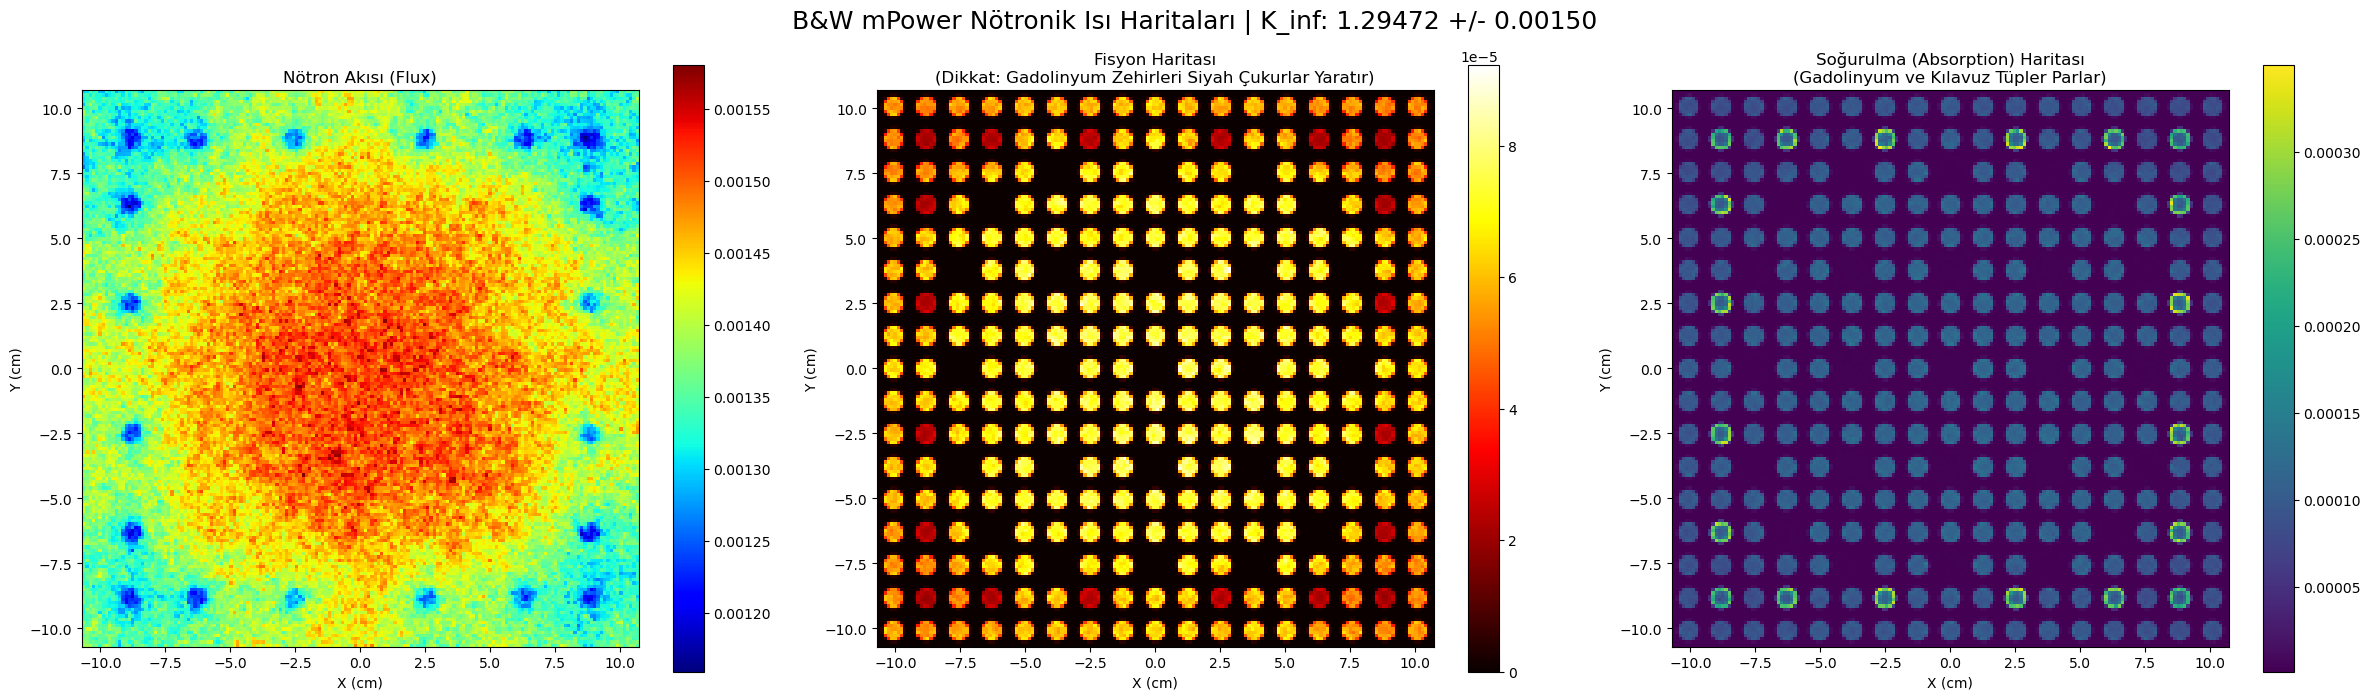

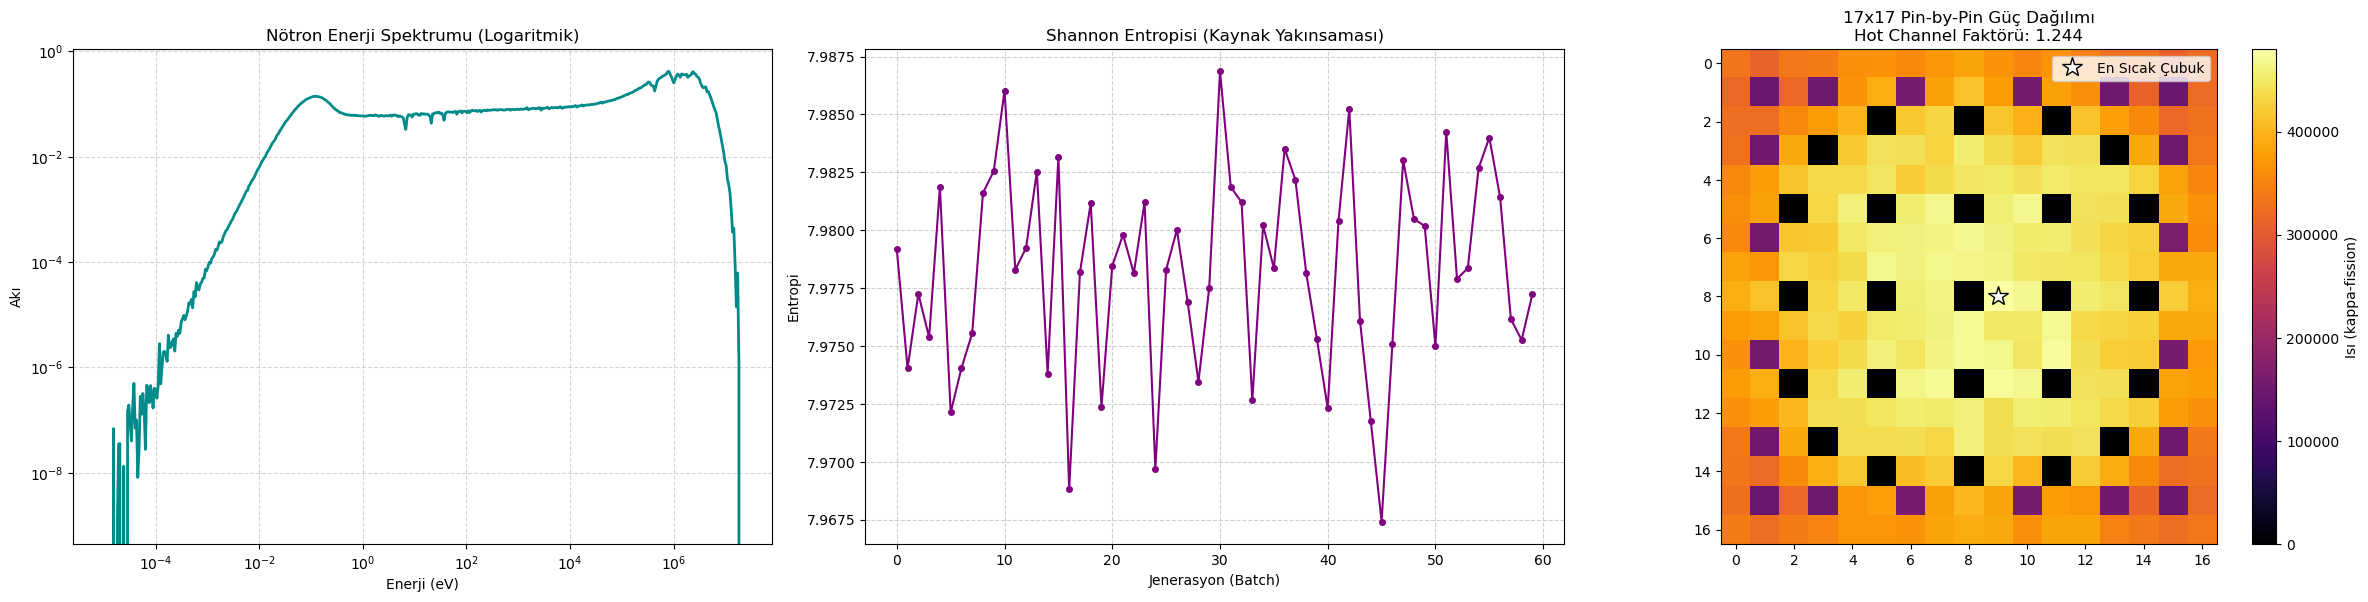

  B&W mPower REAKSİYON İSTATİSTİKLERİ VE RAPORU
K-Effective (Sonsuz Çoğalma)  : 1.29472 +/- 0.00150
Hot Channel (Güç Zirve) Oranı : 1.244 (Güvenli: < 1.5)
Toplam (n,2n) Çoğalma Oranı   : 1.41355e-03
Toplam (n,gamma) Yutulma Oranı: 4.71251e-01


In [6]:
import h5py

print("\nSonuçlar HDF5 Dosyasından Çekiliyor.\n")
statepoint_files = glob.glob('statepoint.*.h5')
latest_sp = max(statepoint_files, key=os.path.getctime)

with openmc.StatePoint(latest_sp) as sp:
    k_inf = sp.keff
    entropy = sp.entropy
    
    spec_t = sp.get_tally(name='Notron_Spektrumu')
    flux_spectrum = spec_t.mean.flatten()
    
    spatial_t = sp.get_tally(name='Uzamsal_Haritalar')
    flux_map = spatial_t.get_slice(scores=['flux']).mean.reshape((170, 170))
    fission_map = spatial_t.get_slice(scores=['fission']).mean.reshape((170, 170))
    abs_map = spatial_t.get_slice(scores=['absorption']).mean.reshape((170, 170))
    
    pin_t = sp.get_tally(name='Pin_Gucu')
    power_map = pin_t.get_slice(scores=['kappa-fission']).mean.reshape((17, 17))
    
    rxn_t = sp.get_tally(name='Global_Reaksiyonlar')
    n2n_rate = rxn_t.get_slice(scores=['(n,2n)']).mean.sum()
    ngamma_rate = rxn_t.get_slice(scores=['(n,gamma)']).mean.sum()

flux_map, fission_map, abs_map, power_map = map(np.flipud, [flux_map, fission_map, abs_map, power_map])
energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])

avg_power = np.mean(power_map[power_map > 0])
max_power = np.max(power_map)
hot_channel_factor = max_power / avg_power

ext = [-mpower_offset, mpower_offset, -mpower_offset, mpower_offset]
fig1, axes1 = plt.subplots(1, 3, figsize=(24, 7))
fig1.suptitle(f'B&W mPower Nötronik Isı Haritaları | K_inf: {k_inf.nominal_value:.5f} +/- {k_inf.std_dev:.5f}', fontsize=18)

im0 = axes1[0].imshow(flux_map, interpolation='nearest', cmap='jet', extent=ext)
axes1[0].set_title('Nötron Akısı (Flux)')
fig1.colorbar(im0, ax=axes1[0])

im1 = axes1[1].imshow(fission_map, interpolation='nearest', cmap='hot', extent=ext)
axes1[1].set_title('Fisyon Haritası\n(Dikkat: Gadolinyum Zehirleri Siyah Çukurlar Yaratır)')
fig1.colorbar(im1, ax=axes1[1])

im2 = axes1[2].imshow(abs_map, interpolation='nearest', cmap='viridis', extent=ext)
axes1[2].set_title('Soğurulma (Absorption) Haritası\n(Gadolinyum ve Kılavuz Tüpler Parlar)')
fig1.colorbar(im2, ax=axes1[2])

for ax in axes1: ax.set_xlabel('X (cm)'); ax.set_ylabel('Y (cm)')
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(24, 6))

# Spektrum
axes2[0].loglog(energy_centers, flux_spectrum, color='darkcyan', linewidth=2)
axes2[0].set_title('Nötron Enerji Spektrumu (Logaritmik)')
axes2[0].set_xlabel('Enerji (eV)')
axes2[0].set_ylabel('Akı')
axes2[0].grid(True, which="both", ls="--", alpha=0.5)

# Entropi
axes2[1].plot(entropy, marker='o', color='purple', markersize=4)
axes2[1].set_title('Shannon Entropisi (Kaynak Yakınsaması)')
axes2[1].set_xlabel('Jenerasyon (Batch)')
axes2[1].set_ylabel('Entropi')
axes2[1].grid(True, linestyle='--', alpha=0.6)

# Pin Gücü
im_pin = axes2[2].imshow(power_map, interpolation='nearest', cmap='inferno')
axes2[2].set_title(f'17x17 Pin-by-Pin Güç Dağılımı\nHot Channel Faktörü: {hot_channel_factor:.3f}')
fig2.colorbar(im_pin, ax=axes2[2], label='Isı (kappa-fission)')
max_idx = np.unravel_index(np.argmax(power_map), power_map.shape)
axes2[2].plot(max_idx[1], max_idx[0], 'w*', markersize=15, markeredgecolor='black', label='En Sıcak Çubuk')
axes2[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("="*55)
print("  B&W mPower REAKSİYON İSTATİSTİKLERİ VE RAPORU")
print("="*55)
print(f"K-Effective (Sonsuz Çoğalma)  : {k_inf.nominal_value:.5f} +/- {k_inf.std_dev:.5f}")
print(f"Hot Channel (Güç Zirve) Oranı : {hot_channel_factor:.3f} (Güvenli: < 1.5)")
print(f"Toplam (n,2n) Çoğalma Oranı   : {n2n_rate:.5e}")
print(f"Toplam (n,gamma) Yutulma Oranı: {ngamma_rate:.5e}")
print("="*55)